**atividade pratica:**

Em vez de um único outlier, adicione vários outliers gerados aleatoriamente aos dados. Experimente com diferentes valores do múltiplo do desvio padrão para identificar outliers, e veja o efeito que isso tem nos resultados finais.

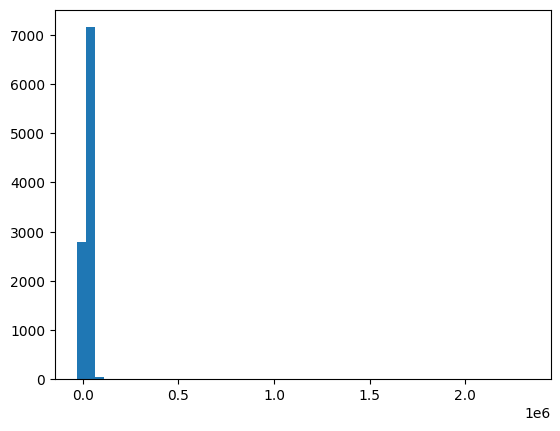

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)  # fixando a seed pra sempre gerar os mesmos outliers ao rodar de novo

incomes = np.random.normal(27000, 15000, 10000)

# em vez de anexar um unico valor gigante, gero vários outliers aleatórios
# valores bem acima da distribuição normal, mas n absurdamente grandes,
# senão qualquer multiplicador de desvio padrão ja os corta de cara
num_outliers = 10
outliers = np.random.uniform(500000, 3000000, num_outliers)
incomes = np.append(incomes, outliers)

plt.hist(incomes, 50)
plt.show()

In [2]:
incomes.mean()  # com os outliers, a média fica bem distorcida em relação ao centro real dos dados

28215.27705612686

In [3]:
# agr a função recebe o múltiplo do desvio padrão como parâmetro,
# em vez de ter o valor 2 fixo no código
def reject_outliers(data, mult):
    u = np.median(data)
    s = np.std(data)
    filtered = [e for e in data if (u - mult * s < e < u + mult * s)]
    return filtered

In [4]:
# testando vários múltiplos do desvio padrão pra comparar o efeito no filtro
# valores pequenos cortam demais (até dado bom); valores grandes deixam os outliers passarem de volta
multipliers = [0.5, 1, 2, 5, 10, 15, 20, 30, 45]

for mult in multipliers:
    filtered = reject_outliers(incomes, mult)
    print(f'mult = {mult:4.1f} -> pontos restantes: {len(filtered):5d} | média: {np.mean(filtered):.2f}')

mult =  0.5 -> pontos restantes:  9258 | média: 26564.43
mult =  1.0 -> pontos restantes:  9998 | média: 26723.35
mult =  2.0 -> pontos restantes: 10000 | média: 26723.49
mult =  5.0 -> pontos restantes: 10000 | média: 26723.49
mult = 10.0 -> pontos restantes: 10000 | média: 26723.49
mult = 15.0 -> pontos restantes: 10002 | média: 26863.05
mult = 20.0 -> pontos restantes: 10003 | média: 26944.16
mult = 30.0 -> pontos restantes: 10006 | média: 27380.46
mult = 45.0 -> pontos restantes: 10010 | média: 28215.28


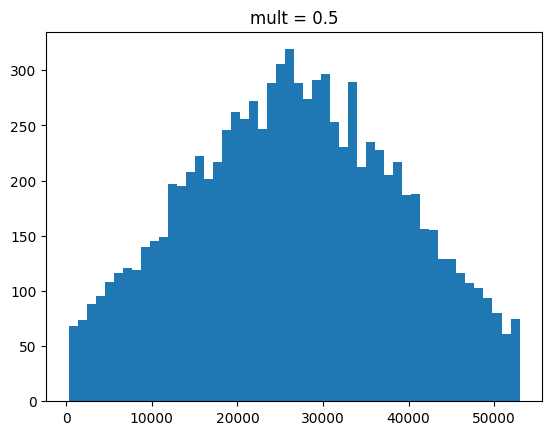

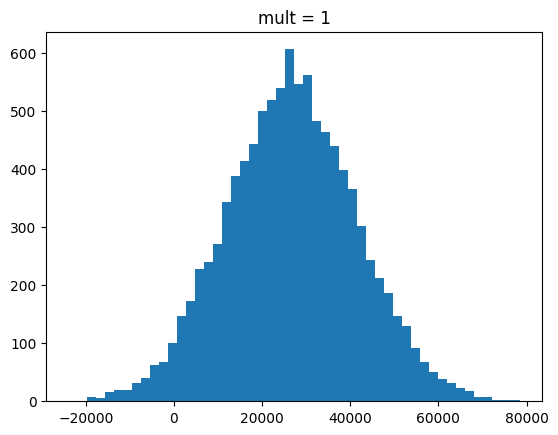

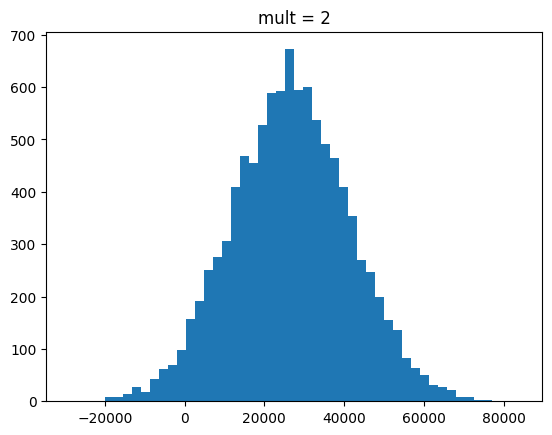

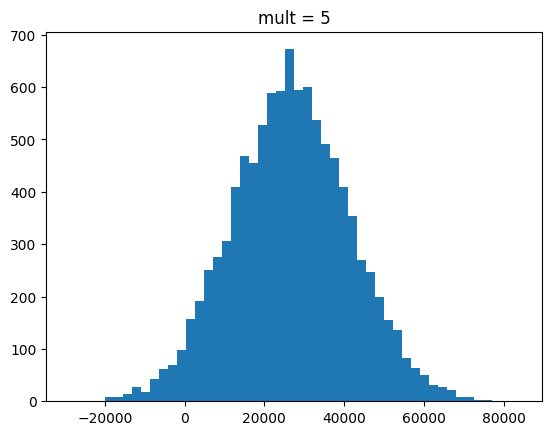

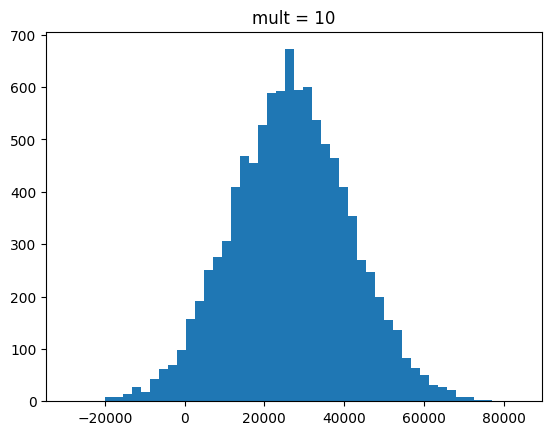

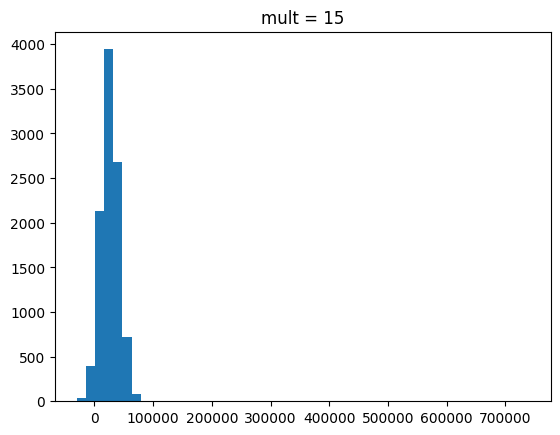

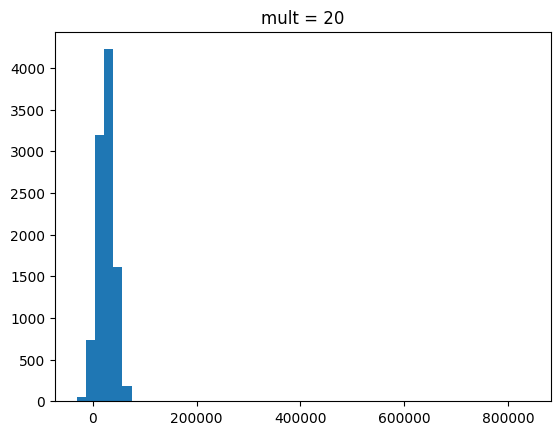

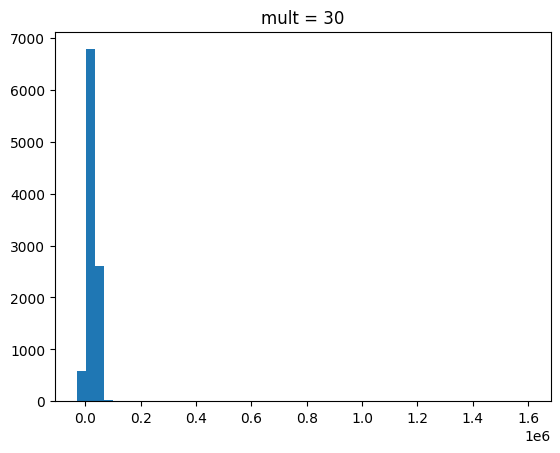

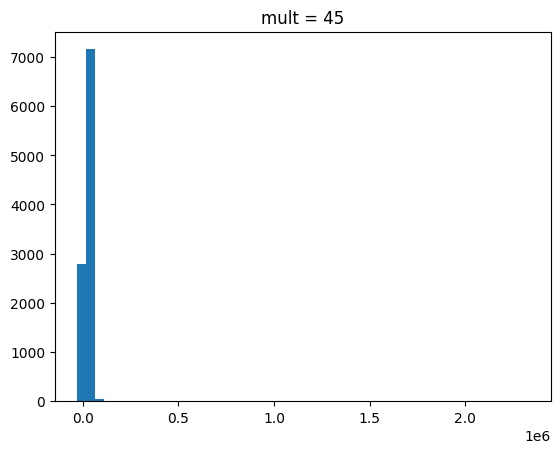

In [5]:
# plotando o histograma resultante pra cada múltiplo, pra ver visualmente o corte acontecendo
for mult in multipliers:
    filtered = reject_outliers(incomes, mult)
    plt.hist(filtered, 50)
    plt.title(f'mult = {mult}')
    plt.show()